# 01 — Baseline Models

**Project:** Syllabus Policy Stance Detection  
**Author:** Charitha  
**Purpose:** Run 5 vanilla models on a balanced dataset, rank by F1-macro, save all models.

---

## What this notebook does:
1. Load the clean dataset from `00_data_preparation.ipynb`
2. Create a **balanced sample** (28 per class = 84 sentences)
3. Split into train/test sets
4. Run 5 models in their **vanilla (default) form**:
   - Logistic Regression + TF-IDF
   - Naive Bayes + TF-IDF
   - Support Vector Machine (SVM) + TF-IDF
   - Random Forest + TF-IDF
   - Zero-Shot BERT (semantic model)
5. Compare all models on F1-macro
6. Save every model to `models/`

---

## Key concept reminder:
- **Independent variable** = sentence text (what we feed the model)
- **Dependent variable** = stance label (what the model predicts)
- **Metric** = F1-macro (equal weight to all 3 classes regardless of size)
- **Vanilla** = default hyperparameters, no tuning yet

---

## Cell 1 — Install Required Libraries
Run this once. After installation, you do not need to run it again.

In [1]:
# Run once to install dependencies
import subprocess
packages = [
    'scikit-learn',
    'pandas',
    'numpy',
    'joblib',
    'matplotlib',
    'seaborn',
    'transformers',
    'torch'
]
for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], capture_output=True)
print('All packages ready!')

All packages ready!


## Cell 2 — Import Libraries

In [2]:
# Data
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text features
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.pipeline import Pipeline

print('All libraries imported successfully!')

All libraries imported successfully!


## Cell 3 — Define Paths and Create Folders

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/policy_relevant_clean.csv'
MODELS_DIR   = '../models/'
RESULTS_DIR  = '../results/'
ANALYSIS_DIR = '../analysis/'

# Create folders if they don't exist
for folder in [MODELS_DIR, RESULTS_DIR, ANALYSIS_DIR]:
    os.makedirs(folder, exist_ok=True)

# Random seed 
RANDOM_SEED = 42

# Stance labels 
LABELS = ['discouraging', 'conditional', 'encouraging']

print('Paths set. Folders ready.')
print(f'Data     : {DATA_PATH}')
print(f'Models   : {MODELS_DIR}')
print(f'Results  : {RESULTS_DIR}')

Paths set. Folders ready.
Data     : ../data/processed/policy_relevant_clean.csv
Models   : ../models/
Results  : ../results/


## Cell 4 — Load Clean Data

In [4]:
df = pd.read_csv(DATA_PATH)

print(f'Loaded: {len(df)} sentences')
print()
print('Stance distribution:')
print(df['stance'].value_counts())
print()
print('Sample rows:')
df.head(3)

Loaded: 354 sentences

Stance distribution:
stance
discouraging    292
conditional      34
encouraging      28
Name: count, dtype: int64

Sample rows:


,sentence,stance
0,IMPORTANT: Note that Wikipedia is reliable for...,conditional
1,Use of sites such as Wikipedia are not allowed...,discouraging
2,"Thus, do not use Wikipedia as your primary sou...",conditional


## Cell 5 — Create Balanced Sample

**Why balance?**  
Our dataset has 292 discouraging, 34 conditional, 28 encouraging.  
If we train on this directly, the model will be biased toward discouraging.  
By sampling equally from each class, we give the model an equal chance to learn all three stances.

**How many per class?**  
We match the smallest class = 28 (encouraging).  
So: 28 discouraging + 28 conditional + 28 encouraging = **84 sentences total**.

**Is 84 enough?**  
For TF-IDF models: yes, as a baseline.  
For transformers: we use all available data (354 sentences) with class weights instead.

In [5]:
# Sample equally from each class
SAMPLES_PER_CLASS = 28

balanced_df = (
    df.groupby('stance')
    .apply(lambda x: x.sample(n=SAMPLES_PER_CLASS, random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

print(f'Balanced dataset size: {len(balanced_df)}')
print()
print('Distribution after balancing:')
print(balanced_df['stance'].value_counts())
print()

# Separate features (X) and labels (y)
# X = independent variable = sentence text
# y = dependent variable   = stance label
X = balanced_df['sentence'].values
y = balanced_df['stance'].values

print(f'X shape: {X.shape}  ← 84 sentences (independent variable)')
print(f'y shape: {y.shape}  ← 84 labels    (dependent variable)') 

Balanced dataset size: 84

Distribution after balancing:
stance
conditional     28
discouraging    28
encouraging     28
Name: count, dtype: int64

X shape: (84,)  ← 84 sentences (independent variable)
y shape: (84,)  ← 84 labels    (dependent variable)


## Cell 6 — Train/Test Split

**Why stratified?**  
Stratified split ensures each class is proportionally represented in both train and test sets.  
Without stratify, you might accidentally get no encouraging sentences in the test set.

**80/20 split:**  
- 80% = 67 sentences for training  
- 20% = 17 sentences for testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y          # ensures proportional class split
)

print(f'Training set   : {len(X_train)} sentences')
print(f'Test set       : {len(X_test)} sentences')
print()
print('Train label distribution:')
train_series = pd.Series(y_train)
print(train_series.value_counts())
print()
print('Test label distribution:')
test_series = pd.Series(y_test)
print(test_series.value_counts())

Training set   : 67 sentences
Test set       : 17 sentences

Train label distribution:
conditional     23
discouraging    22
encouraging     22
Name: count, dtype: int64

Test label distribution:
discouraging    6
encouraging     6
conditional     5
Name: count, dtype: int64


## Cell 7 — Define Helper Functions

We write two reusable functions:
1. `evaluate_model()` : takes a trained model, runs predictions, returns all metrics
2. `plot_confusion_matrix()` : visualizes where the model makes mistakes

Writing functions instead of repeating code = good software practice.

In [7]:
def evaluate_model(model_name, pipeline, X_test, y_test):
    """
    Evaluate a trained sklearn pipeline and return metrics.
    
    Parameters:
        model_name : str         — name for display
        pipeline   : Pipeline    — trained sklearn pipeline
        X_test     : array       — test sentences
        y_test     : array       — true labels
    
    Returns:
        dict with all evaluation metrics
    """
    y_pred = pipeline.predict(X_test)
    
    f1_macro    = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    accuracy    = accuracy_score(y_test, y_pred)
    
    # Per-class F1
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=LABELS)
    
    print(f'\n{"+" + "=" * 58 + "+"}')
    print(f'  Model: {model_name}')
    print(f'{"+" + "=" * 58 + "+"}')
    print(f'  F1-Macro    : {f1_macro:.4f}   ← PRIMARY METRIC')
    print(f'  F1-Weighted : {f1_weighted:.4f}')
    print(f'  Accuracy    : {accuracy:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=LABELS))
    
    return {
        'model'          : model_name,
        'f1_macro'       : round(f1_macro, 4),
        'f1_weighted'    : round(f1_weighted, 4),
        'accuracy'       : round(accuracy, 4),
        'f1_discouraging': round(f1_per_class[0], 4),
        'f1_conditional' : round(f1_per_class[1], 4),
        'f1_encouraging' : round(f1_per_class[2], 4),
        'y_pred'         : y_pred
    }


def plot_confusion_matrix(model_name, y_test, y_pred):
    """
    Plot and save a confusion matrix for a model.
    Rows = true labels, Columns = predicted labels.
    Diagonal = correct predictions.
    Off-diagonal = mistakes.
    """
    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True, fmt='d',
        xticklabels=LABELS,
        yticklabels=LABELS,
        cmap='Blues',
        linewidths=0.5
    )
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    fname = model_name.lower().replace(' ', '_').replace('+', '').replace('__', '_')
    plt.savefig(f'{ANALYSIS_DIR}cm_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Helper functions defined!')

Helper functions defined!


## Cell 8 — Model 1: Logistic Regression + TF-IDF

**What is a Pipeline?**  
A Pipeline chains steps together. When you call `pipeline.fit(X_train, y_train)`, it:
1. Fits TF-IDF on X_train → converts sentences to numbers
2. Feeds those numbers into Logistic Regression → trains the classifier

When you call `pipeline.predict(X_test)`, it:
1. Transforms X_test using the SAME TF-IDF (already fitted)
2. Predicts using the trained classifier

**Why Logistic Regression?**  
Strong text classification baseline. Interpretable. Fast. Works well with TF-IDF.


+==========================================================+
  Model: Logistic Regression + TF-IDF
+==========================================================+
  F1-Macro    : 0.4286   ← PRIMARY METRIC
  F1-Weighted : 0.4370
  Accuracy    : 0.4118

              precision    recall  f1-score   support

discouraging       0.22      0.40      0.29         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.75      0.50      0.60         6

    accuracy                           0.41        17
   macro avg       0.49      0.41      0.43        17
weighted avg       0.51      0.41      0.44        17



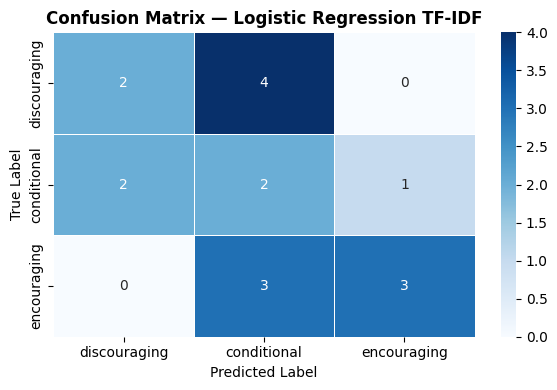

Model saved: lr_tfidf_vanilla.pkl


In [8]:
# Build the pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),   # unigrams + bigrams
        max_features=5000,    # top 5000 most important terms
        sublinear_tf=True     # apply log normalization to term frequency
    )),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        random_state=RANDOM_SEED
        # NOTE: no class_weight here — data is already balanced
    ))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Evaluate
lr_results = evaluate_model('Logistic Regression + TF-IDF', lr_pipeline, X_test, y_test)

# Confusion matrix
plot_confusion_matrix('Logistic Regression TF-IDF', y_test, lr_results['y_pred'])

# Save model
joblib.dump(lr_pipeline, f'{MODELS_DIR}lr_tfidf_vanilla.pkl')
print('Model saved: lr_tfidf_vanilla.pkl')

## Cell 9 — Model 2: Naive Bayes + TF-IDF

**What is Naive Bayes?**  
A probabilistic classifier based on Bayes' theorem. It calculates the probability that a sentence belongs to each class based on the words it contains.  
Called 'naive' because it assumes all words are independent of each other which is not true in reality, but still works surprisingly well for text.

**Why include it?**  
Classic text classification baseline. Very fast. Known to work well on small datasets.


+==========================================================+
  Model: Naive Bayes + TF-IDF
+==========================================================+
  F1-Macro    : 0.4387   ← PRIMARY METRIC
  F1-Weighted : 0.4477
  Accuracy    : 0.4118

              precision    recall  f1-score   support

discouraging       0.22      0.40      0.29         5
 conditional       0.40      0.33      0.36         6
 encouraging       1.00      0.50      0.67         6

    accuracy                           0.41        17
   macro avg       0.54      0.41      0.44        17
weighted avg       0.56      0.41      0.45        17



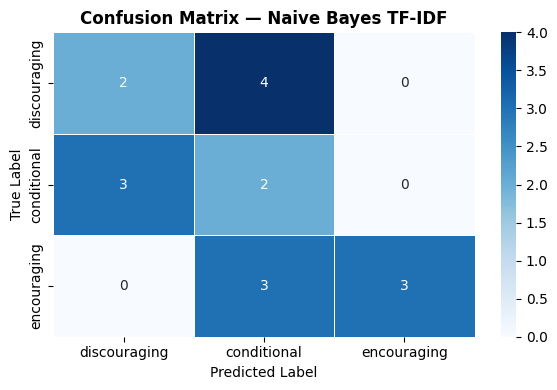

Model saved: nb_tfidf_vanilla.pkl


In [9]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ('clf', MultinomialNB())
    # NOTE: MultinomialNB needs non-negative values
    # TF-IDF always produces non-negative values so this is fine
])

# Train
nb_pipeline.fit(X_train, y_train)

# Evaluate
nb_results = evaluate_model('Naive Bayes + TF-IDF', nb_pipeline, X_test, y_test)

# Confusion matrix
plot_confusion_matrix('Naive Bayes TF-IDF', y_test, nb_results['y_pred'])

# Save
joblib.dump(nb_pipeline, f'{MODELS_DIR}nb_tfidf_vanilla.pkl')
print('Model saved: nb_tfidf_vanilla.pkl')

## Cell 10 — Model 3: SVM + TF-IDF

**What is SVM?**  
Support Vector Machine. It finds the best boundary (hyperplane) that separates classes with maximum margin.  
In text classification, SVM is often the strongest TF-IDF-based model because it handles high-dimensional sparse data (lots of words, mostly zeros) very well.

**LinearSVC** = faster version of SVM optimized for text. This is the one to use with TF-IDF.


+==========================================================+
  Model: SVM + TF-IDF
+==========================================================+
  F1-Macro    : 0.4177   ← PRIMARY METRIC
  F1-Weighted : 0.4242
  Accuracy    : 0.4118

              precision    recall  f1-score   support

discouraging       0.25      0.40      0.31         5
 conditional       0.50      0.33      0.40         6
 encouraging       0.60      0.50      0.55         6

    accuracy                           0.41        17
   macro avg       0.45      0.41      0.42        17
weighted avg       0.46      0.41      0.42        17



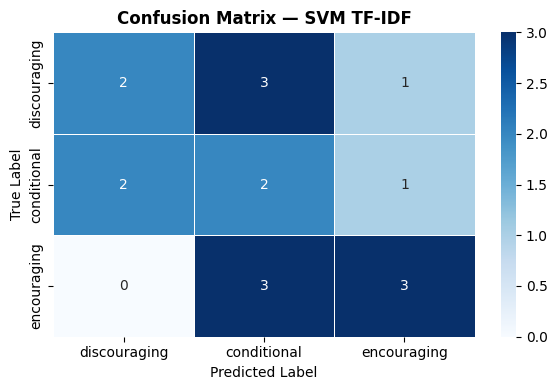

Model saved: svm_tfidf_vanilla.pkl


In [10]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        max_iter=2000,
        random_state=RANDOM_SEED
    ))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Evaluate
svm_results = evaluate_model('SVM + TF-IDF', svm_pipeline, X_test, y_test)

# Confusion matrix
plot_confusion_matrix('SVM TF-IDF', y_test, svm_results['y_pred'])

# Save
joblib.dump(svm_pipeline, f'{MODELS_DIR}svm_tfidf_vanilla.pkl')
print('Model saved: svm_tfidf_vanilla.pkl')

## Cell 11 — Model 4: Random Forest + TF-IDF

**What is Random Forest?**  
An ensemble of many decision trees. Each tree is trained on a random subset of the data and features. The final prediction is a majority vote across all trees.

**Why include it?**  
It handles noise well and is robust to overfitting. On small datasets it can sometimes outperform simpler models. It also gives feature importances useful for understanding which words drive stance predictions.


+==========================================================+
  Model: Random Forest + TF-IDF
+==========================================================+
  F1-Macro    : 0.3927   ← PRIMARY METRIC
  F1-Weighted : 0.4027
  Accuracy    : 0.4706

              precision    recall  f1-score   support

discouraging       0.25      0.20      0.22         5
 conditional       0.50      0.17      0.25         6
 encouraging       0.55      1.00      0.71         6

    accuracy                           0.47        17
   macro avg       0.43      0.46      0.39        17
weighted avg       0.44      0.47      0.40        17



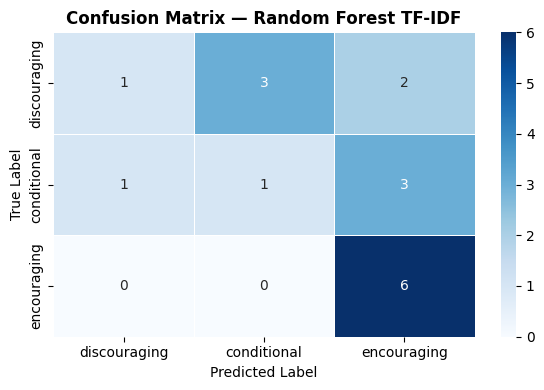

Model saved: rf_tfidf_vanilla.pkl


In [11]:
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(
        n_estimators=100,      # 100 trees
        random_state=RANDOM_SEED
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Evaluate
rf_results = evaluate_model('Random Forest + TF-IDF', rf_pipeline, X_test, y_test)

# Confusion matrix
plot_confusion_matrix('Random Forest TF-IDF', y_test, rf_results['y_pred'])

# Save
joblib.dump(rf_pipeline, f'{MODELS_DIR}rf_tfidf_vanilla.pkl')
print('Model saved: rf_tfidf_vanilla.pkl')

## Cell 12 — Model 5: Zero-Shot BERT

**What is Zero-Shot Classification?**  
Zero-shot means the model has never seen YOUR labels (discouraging/conditional/encouraging) during training. Instead, it uses natural language understanding to decide which label best fits the sentence just from the meaning of the label words.

**Why is this semantic?**  
BERT reads the whole sentence as a unit. It understands context, negation, and contrast exactly what TF-IDF cannot do. This is why your mentor said to look into semantic approaches.

**Note:** This cell downloads a model (~1.5GB) the first time. After that it is cached locally.

Loading zero-shot classifier...
(First run downloads ~1.5GB model — please wait)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use mps:0


Model loaded!

Running predictions on 17 test sentences...
  Processed 5/17
  Processed 10/17
  Processed 15/17

+==========================================================+
  Model: Zero-Shot BERT (facebook/bart-large-mnli)
+==========================================================+
  F1-Macro    : 0.6465   ← PRIMARY METRIC
  F1-Weighted : 0.6524
  Accuracy    : 0.6471

              precision    recall  f1-score   support

discouraging       0.50      0.60      0.55         5
 conditional       0.67      0.67      0.67         6
 encouraging       0.80      0.67      0.73         6

    accuracy                           0.65        17
   macro avg       0.66      0.64      0.65        17
weighted avg       0.66      0.65      0.65        17



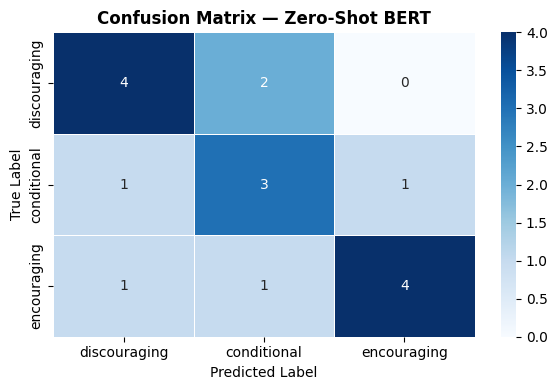

Model saved: zeroshot_bert_vanilla.pkl


In [12]:
from transformers import pipeline as hf_pipeline

print('Loading zero-shot classifier...')
print('(First run downloads ~1.5GB model — please wait)')

# Load zero-shot pipeline from HuggingFace
zero_shot = hf_pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli'
)

# Candidate labels — these are the natural language descriptions
# we pass to the model. Better descriptions = better predictions.
candidate_labels = [
    'discouraging or prohibiting Wikipedia use',
    'conditionally allowing Wikipedia use with restrictions',
    'encouraging or recommending Wikipedia use'
]

# Map verbose labels back to our short labels
label_map = {
    'discouraging or prohibiting Wikipedia use'             : 'discouraging',
    'conditionally allowing Wikipedia use with restrictions': 'conditional',
    'encouraging or recommending Wikipedia use'             : 'encouraging'
}

print('Model loaded!')
print()

# Run predictions on test set
print(f'Running predictions on {len(X_test)} test sentences...')
zs_preds = []
for i, sentence in enumerate(X_test):
    result = zero_shot(sentence, candidate_labels)
    best_label = label_map[result['labels'][0]]  # highest scoring label
    zs_preds.append(best_label)
    if (i + 1) % 5 == 0:
        print(f'  Processed {i+1}/{len(X_test)}')

zs_preds = np.array(zs_preds)

# Evaluate manually (zero-shot has no sklearn .predict)
f1_macro    = f1_score(y_test, zs_preds, average='macro')
f1_weighted = f1_score(y_test, zs_preds, average='weighted')
accuracy    = accuracy_score(y_test, zs_preds)
f1_per_class = f1_score(y_test, zs_preds, average=None, labels=LABELS)

print(f'\n{"+" + "=" * 58 + "+"}')
print(f'  Model: Zero-Shot BERT (facebook/bart-large-mnli)')
print(f'{"+" + "=" * 58 + "+"}')
print(f'  F1-Macro    : {f1_macro:.4f}   ← PRIMARY METRIC')
print(f'  F1-Weighted : {f1_weighted:.4f}')
print(f'  Accuracy    : {accuracy:.4f}')
print()
print(classification_report(y_test, zs_preds, target_names=LABELS))

zs_results = {
    'model'          : 'Zero-Shot BERT',
    'f1_macro'       : round(f1_macro, 4),
    'f1_weighted'    : round(f1_weighted, 4),
    'accuracy'       : round(accuracy, 4),
    'f1_discouraging': round(f1_per_class[0], 4),
    'f1_conditional' : round(f1_per_class[1], 4),
    'f1_encouraging' : round(f1_per_class[2], 4),
    'y_pred'         : zs_preds
}

plot_confusion_matrix('Zero-Shot BERT', y_test, zs_preds)

# Save the pipeline object for zero-shot
joblib.dump(zero_shot, f'{MODELS_DIR}zeroshot_bert_vanilla.pkl')
print('Model saved: zeroshot_bert_vanilla.pkl')

## Cell 13 — Model Comparison Table

Rank all models by F1-macro. This is the output you show your mentor.  
It directly answers: *which vanilla model performs best on balanced stance classification?*

In [13]:
# Collect all results
all_results = [
    lr_results,
    nb_results,
    svm_results,
    rf_results,
    zs_results
]

# Build comparison dataframe
comparison_cols = [
    'model', 'f1_macro', 'f1_weighted', 'accuracy',
    'f1_discouraging', 'f1_conditional', 'f1_encouraging'
]
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in all_results
])

# Sort by F1-macro descending
results_df = results_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)
results_df.index += 1  # rank starts at 1

print('=' * 80)
print('   BASELINE MODEL COMPARISON — Ranked by F1-Macro')
print('=' * 80)
print(results_df[comparison_cols].to_string())
print()
print(f'Best model (F1-macro): {results_df.iloc[0]["model"]} ({results_df.iloc[0]["f1_macro"]})')

# Save results
results_df.to_csv(f'{RESULTS_DIR}01_baseline_comparison.csv', index=True)
print(f'\nResults saved: {RESULTS_DIR}01_baseline_comparison.csv')

   BASELINE MODEL COMPARISON — Ranked by F1-Macro
                          model  f1_macro  f1_weighted  accuracy  f1_discouraging  f1_conditional  f1_encouraging
1                Zero-Shot BERT    0.6465       0.6524    0.6471           0.6667          0.5455          0.7273
2          Naive Bayes + TF-IDF    0.4387       0.4477    0.4118           0.3636          0.2857          0.6667
3  Logistic Regression + TF-IDF    0.4286       0.4370    0.4118           0.4000          0.2857          0.6000
4                  SVM + TF-IDF    0.4177       0.4242    0.4118           0.4000          0.3077          0.5455
5        Random Forest + TF-IDF    0.3927       0.4027    0.4706           0.2500          0.2222          0.7059

Best model (F1-macro): Zero-Shot BERT (0.6465)

Results saved: ../results/01_baseline_comparison.csv


## Cell 14 — Visualize Model Comparison

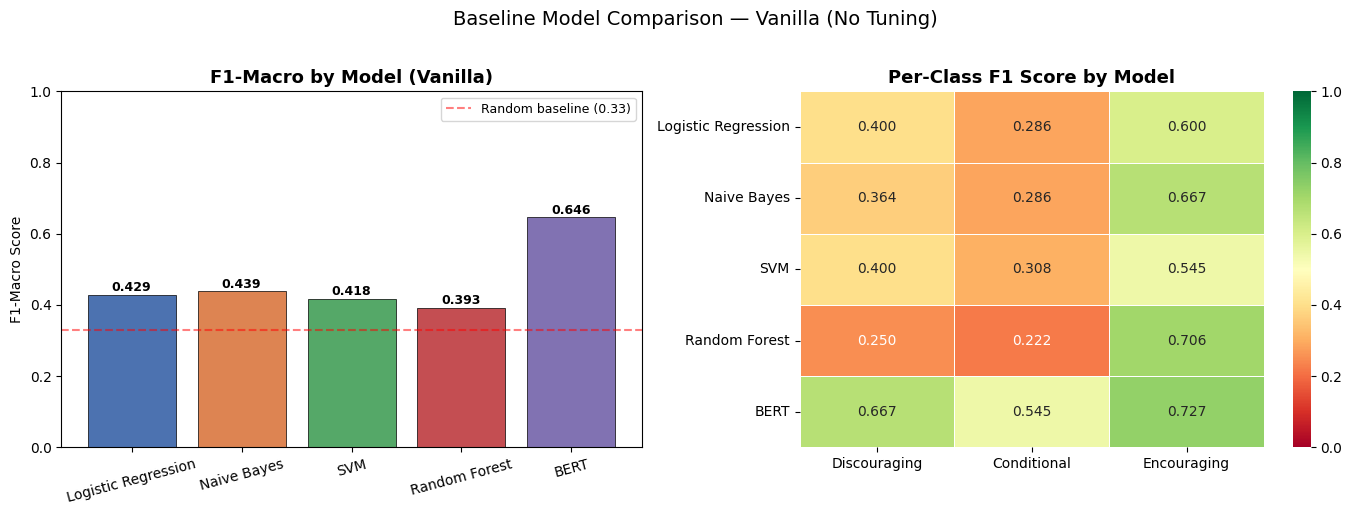

Figure saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_short = [
    r['model'].replace(' + TF-IDF', '').replace('Zero-Shot ', '')
    for r in all_results
]

# ── Plot 1: F1-Macro comparison ─────────────────────────────────────────
f1_macros = [r['f1_macro'] for r in all_results]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

bars = axes[0].bar(models_short, f1_macros, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('F1-Macro by Model (Vanilla)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Macro Score')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=0.33, color='red', linestyle='--', alpha=0.5, label='Random baseline (0.33)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, f1_macros):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# ── Plot 2: Per-class F1 heatmap ────────────────────────────────────────
per_class_data = pd.DataFrame({
    'Model'         : models_short,
    'Discouraging'  : [r['f1_discouraging'] for r in all_results],
    'Conditional'   : [r['f1_conditional']  for r in all_results],
    'Encouraging'   : [r['f1_encouraging']  for r in all_results],
}).set_index('Model')

sns.heatmap(
    per_class_data,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Baseline Model Comparison — Vanilla (No Tuning)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}01_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

## Cell 15 — Cross-Validation on Best TF-IDF Model

**Why cross-validation?**  
A single train/test split of 84 sentences is small results might vary depending on which sentences ended up in the test set. Cross-validation splits the data into 5 folds, trains and tests 5 times, and averages the results. This gives a more stable, reliable estimate of true performance.

In [15]:
# Run 5-fold cross validation on all TF-IDF models
print('Running 5-fold cross-validation on balanced dataset...')
print()

cv_models = {
    'Logistic Regression': lr_pipeline,
    'Naive Bayes'        : nb_pipeline,
    'SVM'                : svm_pipeline,
    'Random Forest'      : rf_pipeline
}

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, model in cv_models.items():
    scores = cross_val_score(
        model, X, y,
        cv=skf,
        scoring='f1_macro'
    )
    cv_results[name] = scores
    print(f'{name:<25} CV F1-Macro: {scores.mean():.4f} (+/- {scores.std():.4f})')

print()
print('Interpretation: mean +/- std across 5 folds')
print('Lower std = more stable model')

Running 5-fold cross-validation on balanced dataset...

Logistic Regression       CV F1-Macro: 0.5171 (+/- 0.1050)
Naive Bayes               CV F1-Macro: 0.4718 (+/- 0.0362)
SVM                       CV F1-Macro: 0.5066 (+/- 0.1032)
Random Forest             CV F1-Macro: 0.4451 (+/- 0.1318)

Interpretation: mean +/- std across 5 folds
Lower std = more stable model


## Cell 16 — Summary and Next Steps

In [16]:
print('=' * 60)
print('  NOTEBOOK 01 COMPLETE — SUMMARY')
print('=' * 60)
print()
print('What we did:')
print('  1. Loaded 354 clean policy-relevant sentences')
print('  2. Created balanced sample: 28 per class = 84 total')
print('  3. Ran 5 vanilla models')
print('  4. Ranked by F1-macro')
print('  5. Saved all models to models/')
print('  6. Ran 5-fold cross-validation for stability check')
print()
print('Models saved:')
for f in os.listdir(MODELS_DIR):
    print(f'  models/{f}')
print()
print('Next step: 02_hyperparameter_tuning.ipynb')
print('  - Take top 2-3 models')
print('  - Run GridSearchCV')
print('  - Find optimal hyperparameters')
print('=' * 60)

  NOTEBOOK 01 COMPLETE — SUMMARY

What we did:
  1. Loaded 354 clean policy-relevant sentences
  2. Created balanced sample: 28 per class = 84 total
  3. Ran 5 vanilla models
  4. Ranked by F1-macro
  5. Saved all models to models/
  6. Ran 5-fold cross-validation for stability check

Models saved:
  models/zeroshot_bert_vanilla.pkl
  models/nb_tfidf_vanilla.pkl
  models/lr_tfidf_vanilla.pkl
  models/rf_tfidf_vanilla.pkl
  models/svm_tfidf_vanilla.pkl

Next step: 02_hyperparameter_tuning.ipynb
  - Take top 2-3 models
  - Run GridSearchCV
  - Find optimal hyperparameters
